# Titanic Dataset: Visualization Ethics and Communication
### Jay Beladiya

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load the Titanic training data
df = pd.read_csv("data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Exploration

### Dataset Structure and Missing Values

In [2]:
# column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# how many missing values are in each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

`Age`, `Cabin`, and `Embarked` all have missing values. `Age` is missing
for about 20% of passengers and `Cabin` is missing for most of them, which
is worth keeping in mind since any chart using those columns is only based
on the passengers who have that data.

### Summary Statistics

In [4]:
# summary statistics (mean, min, max, quartiles, etc.) for numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Outliers in Age and Fare (Boxplots)

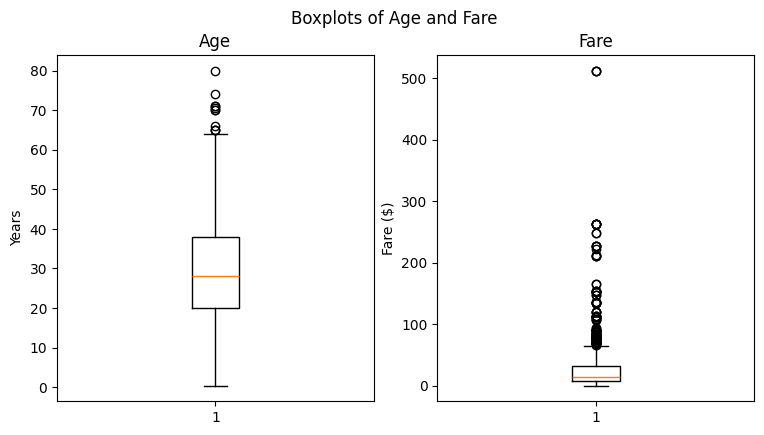

In [5]:
# boxplots for Age and Fare side by side; dropna() since Age has missing values
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

axes[0].boxplot(df["Age"].dropna())
axes[0].set_title("Age")
axes[0].set_ylabel("Years")

axes[1].boxplot(df["Fare"].dropna())
axes[1].set_title("Fare")
axes[1].set_ylabel("Fare ($)")

plt.suptitle("Boxplots of Age and Fare")
plt.show()

### Counting Outliers with the IQR Rule

In [6]:
# standard IQR rule: anything outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] is an outlier
def count_outliers(column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), lower, upper

# print the outlier count and normal range for each column
for column in ["Age", "Fare"]:
    n_outliers, lower, upper = count_outliers(column)
    print(f"{column}: {n_outliers} outliers (normal range: {lower:.2f} to {upper:.2f})")

Age: 11 outliers (normal range: -6.69 to 64.81)
Fare: 116 outliers (normal range: -26.72 to 65.63)


`Fare` has a substantial number of outliers, mostly very wealthy
passengers who paid far more than a typical ticket price. `Age` has far
fewer outliers, mostly a handful of elderly passengers. These outliers are
real, valid data points, but it's important to be aware of them since a
few extreme values can distort a chart's scale.

## Accurate Visualization 1: Survival Rate by Age Group (Line Chart)

This chart groups passengers into 10-year age bands and plots the survival
rate for each band, showing how the chance of survival changed with age.

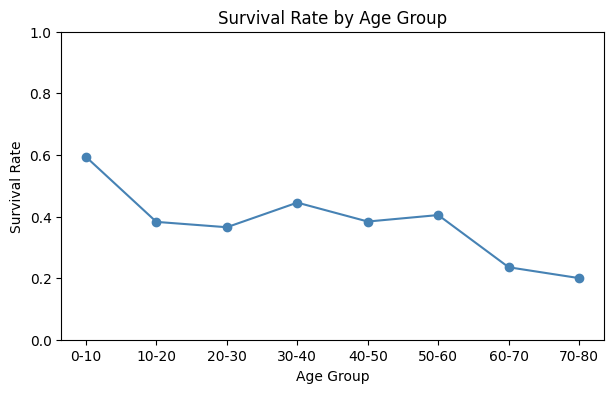

In [7]:
# split passengers into 10-year age bands
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

# average survival rate within each age band
survival_by_age = df.groupby("AgeGroup", observed=True)["Survived"].mean()

plt.figure(figsize=(7, 4))
plt.plot(survival_by_age.index, survival_by_age.values, marker="o", color="steelblue")
plt.ylim(0, 1)  # full 0-100% range so the trend isn't exaggerated
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group")
plt.show()

**Why this is effective:** A line chart is a natural fit here because age
groups have a real order (youngest to oldest), so connecting the points lets
the reader see a trend rather than just isolated values. The y-axis runs the
full 0 to 1 range, so the shape of the line honestly reflects the size of
the differences. The chart clearly shows young children had a notable
survival advantage.

## Accurate Visualization 2: Age vs. Fare, Colored by Survival (Scatter Plot)

This scatter plot shows every passenger as a point positioned by age and
fare paid, colored by whether they survived. It lets us look at two
numeric variables and an outcome at the same time.

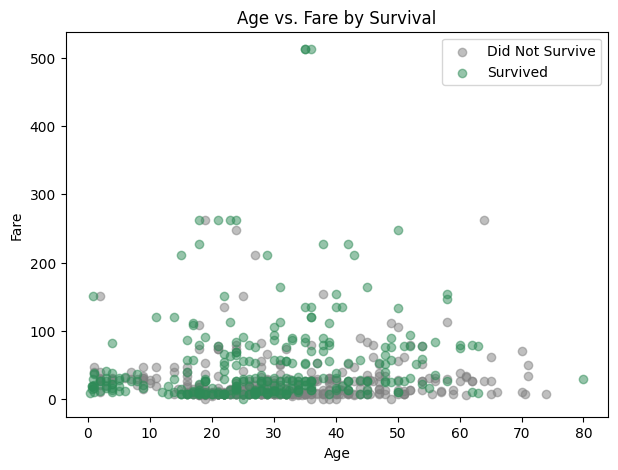

In [8]:
# split into two groups so each can be given its own color
survived = df[df["Survived"] == 1]
died = df[df["Survived"] == 0]

plt.figure(figsize=(7, 5))
# alpha makes overlapping points still visible instead of hiding each other
plt.scatter(died["Age"], died["Fare"], alpha=0.5, color="gray", label="Did Not Survive")
plt.scatter(survived["Age"], survived["Fare"], alpha=0.5, color="seagreen", label="Survived")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs. Fare by Survival")
plt.legend()
plt.show()

**Why this is effective:** Every passenger is plotted individually with no
binning or averaging, so no information is hidden or summarized away.
Transparency (`alpha=0.5`) is used so overlapping points are still visible
rather than hiding each other. The chart honestly shows that passengers who
paid higher fares (generally 1st class) were more likely to survive.

## Misleading Visualization 1: Truncated Y-Axis (Bar Chart)

This bar chart shows survival rate by passenger class, but the y-axis is
truncated to start at 0.20 instead of 0.

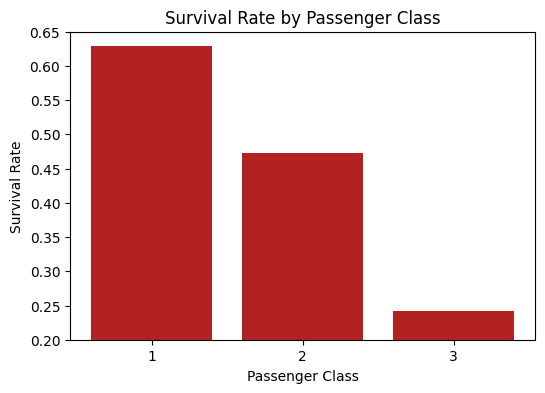

In [9]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6, 4))
plt.bar(survival_by_class.index.astype(str), survival_by_class.values, color="firebrick")
plt.ylim(0.20, 0.65)  # truncated axis -- this is the misleading part
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.show()

**How this misleads:** This graph uses the exact same accurate survival-rate-by-class dataset as another previous chart, except that the y-axis is truncated from 0 up to 0.20. Since bar charts rely on relative bar height as their primary visual, truncating the y-axis makes the shorter bars shrink more compared to the taller ones. In the data, the 1st class survival rate is 63% which is 2.5 times the 3rd class survival rate (24%), but in the graph the 1st class bar appears 10 times taller than the 3rd class bar. 

## Misleading Visualization 2: Same-Size Pie Charts With Different Totals

These two pie charts show survival outcome for male and female passengers
separately, drawn at the same physical size, with no indication of how many
people each pie actually represents.

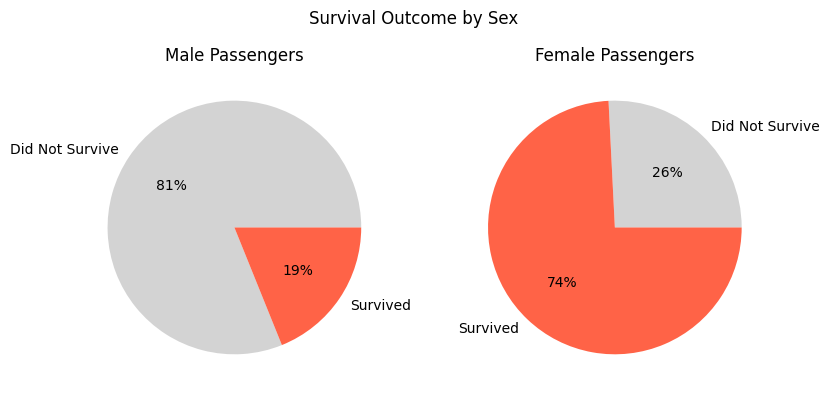

In [10]:
male = df[df["Sex"] == "male"]
female = df[df["Sex"] == "female"]

# counts of survived (1) vs did not survive (0) for each sex
male_counts = male["Survived"].value_counts().sort_index()
female_counts = female["Survived"].value_counts().sort_index()

# both pies are the same size even though male/female totals are very different -- the misleading part
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].pie(male_counts, labels=["Did Not Survive", "Survived"], autopct="%1.0f%%",
            colors=["lightgray", "tomato"])
axes[0].set_title("Male Passengers")

axes[1].pie(female_counts, labels=["Did Not Survive", "Survived"], autopct="%1.0f%%",
            colors=["lightgray", "tomato"])
axes[1].set_title("Female Passengers")

plt.suptitle("Survival Outcome by Sex")
plt.show()

**How this misleads:** The two pies are drawn at identical size, which
visually implies they represent comparable groups. In reality there were
577 male passengers and only 314 female passengers, nearly twice as many
men as women, but nothing on the chart reveals that difference. A reader
naturally assumes equal-sized pies represent equal-sized groups, so this
chart hides the fact that the striking 74% female survival figure is based
on a much smaller total population than the 19% male figure.